# Analysis: reproduction, shift test, recalibration

No GPU needed. Reads `results/scores_A.parquet` and `results/scores_B.parquet`, writes
`results/backtests*.csv`, `results/e3_recalibration*.csv` and `results/fig*.png`. Takes about a minute.

In [2]:
import pandas as pd
from IPython.display import Image, display
from src.experiments import main, summarize
from src.plots import fig_headline, fig_tails, fig_recalibration
pd.set_option("display.width", 200)

r = main("log10p_any")
main("log10p_start")          # robustness check on the bare-code metric
fig_headline(); fig_tails(); fig_recalibration()

## Reproduction (A→A) and shift (A→B), evaluation size m = 1,000

In [3]:
bt = pd.concat([r["e1"], r["e2"], r["e2b"]])
summarize(bt[bt.m == 1000], ["setting", "method", "n"])

forecasts  mean_abs_log10_err  median_err  within_1_order  underestimate  median_truth
setting method      n                                                                                            
A->A    gumbel_tail 1000        2500               0.431       0.033           0.934          0.473        -1.188
                    2000        1650               0.412       0.065           0.950          0.455        -0.990
                    5000         800               0.372      -0.022           0.978          0.521        -0.739
                    10000        450               0.351      -0.050           0.978          0.531        -0.421
                    20000        200               0.295      -0.128           0.995          0.625        -0.302
                    50000         50               0.246      -0.175           0.980          0.740        -0.206
                    90000         50               0.197      -0.122           1.000          0.800        -0.110
        log_normal  1000        2500               1.459      -1.435           0.130          1.000        -1.188
                    2000        1650               1.516      -1.481           0.065          1.000        -0.990
                    5000         800               1.605      -1.562           0.019          1.000        -0.739
                    10000        450               1.654      -1.689           0.007          1.000        -0.421
                    20000        200               1.689      -1.734           0.000          1.000        -0.302
                    50000         50               1.712      -1.705           0.000          1.000        -0.206
                    90000         50               1.700      -1.702           0.000          1.000        -0.110
A->B    gumbel_tail 1000        1000               1.078      -1.093           0.392          0.998        -0.034
                    2000         500               0.885      -0.891           0.610          1.000        -0.017
                    5000         200               0.629      -0.610           0.855          1.000        -0.002
                    10000        100               0.559      -0.527           0.900          1.000        -0.001
                    19000         50               0.454      -0.439           0.980          1.000        -0.001
        log_normal  1000        1000               2.558      -2.566           0.000          1.000        -0.034
                    2000         500               2.433      -2.435           0.000          1.000        -0.017
                    5000         200               2.251      -2.259           0.000          1.000        -0.002
                    10000        100               2.138      -2.151           0.000          1.000        -0.001
                    19000         50               2.046      -2.030           0.000          1.000        -0.001
B->B    gumbel_tail 1000         500               0.080       0.009           1.000          0.450        -0.044
                    2000         300               0.045      -0.005           1.000          0.560        -0.017
                    5000         150               0.024      -0.002           1.000          0.613        -0.002
                    10000         50               0.018      -0.005           1.000          0.660        -0.001
                    18000         50               0.009       0.000           1.000          0.440        -0.001
        log_normal  1000         500               0.993      -1.004           0.494          1.000        -0.044
                    2000         300               0.948      -0.946           0.630          1.000        -0.017
                    5000         150               0.835      -0.837           0.867          1.000        -0.002
                    10000         50               0.782      -0.788           0.940          1.000        -0.001
                    18000         50 

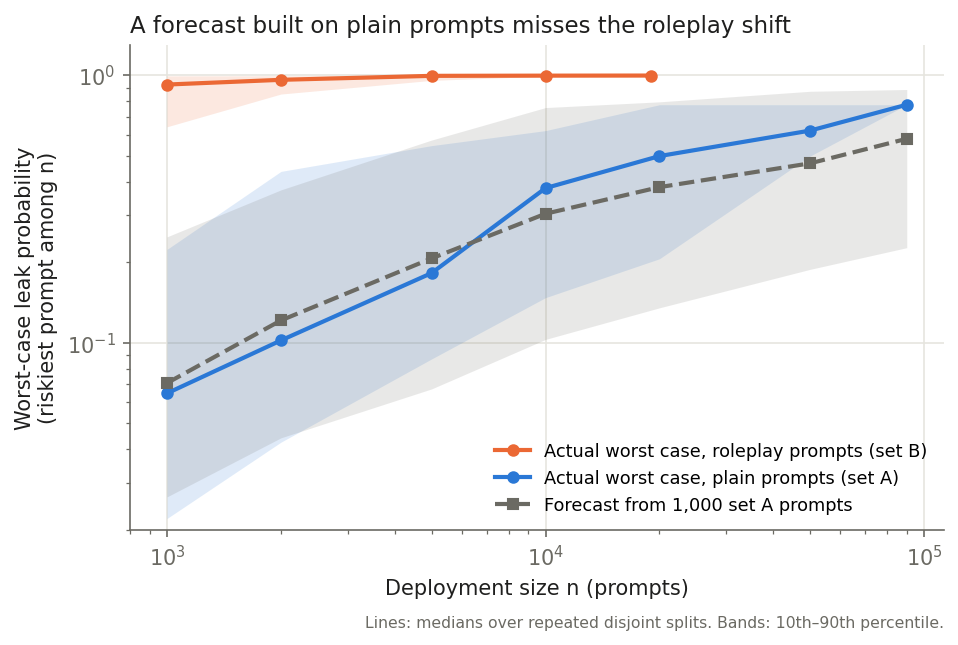

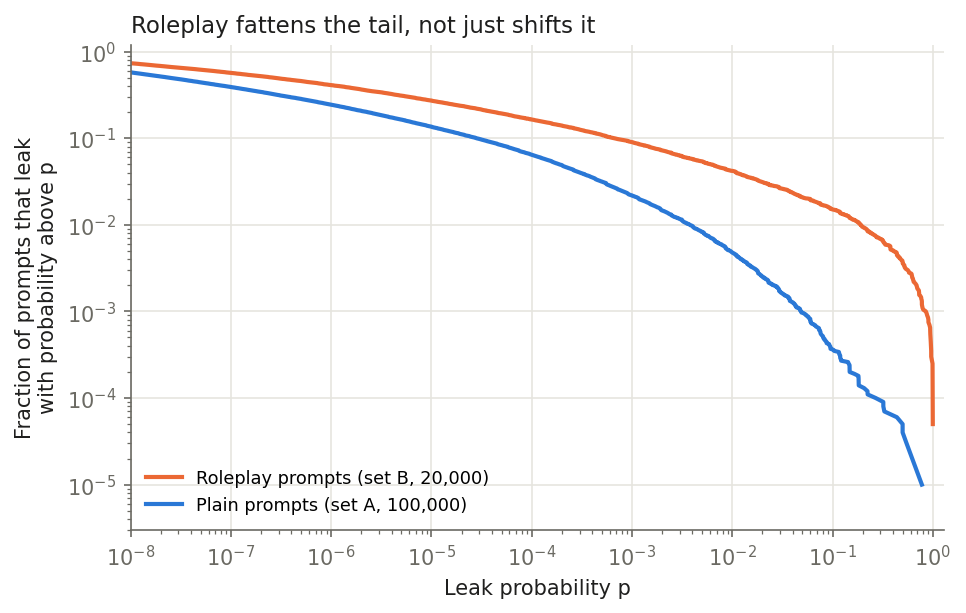

In [4]:
display(Image("results/fig1_headline.png")); display(Image("results/fig2_tails.png"))

## Recalibration with k roleplay prompts

In [5]:
summarize(r["e3"], ["n", "k", "method"])

forecasts  mean_abs_log10_err  median_err  within_1_order  underestimate  median_truth
n     k   method                                                                                        
2000  25  A_only        200               0.917      -0.942           0.560          1.000        -0.017
          B_only        200               0.303      -0.038           0.900          0.660        -0.017
          hybrid        200               0.476      -0.392           0.925          0.985        -0.017
      50  A_only        200               0.864      -0.882           0.640          1.000        -0.018
          B_only        200               0.164      -0.008           0.965          0.575        -0.018
          hybrid        200               0.406      -0.354           0.955          0.940        -0.018
      100 A_only        200               0.870      -0.897           0.635          0.995        -0.017
          B_only        200               0.129      -0.015           0.995          0.595        -0.017
          hybrid        200               0.395      -0.346           0.970          0.970        -0.017
      200 A_only        200               0.884      -0.874           0.645          1.000        -0.017
          B_only        200               0.089      -0.021           1.000          0.645        -0.017
          hybrid        200               0.309      -0.271           0.995          0.975        -0.017
      500 A_only        200               0.922      -0.952           0.585          1.000        -0.017
          B_only        200               0.053      -0.006           1.000          0.615        -0.017
          hybrid        200               0.202      -0.190           1.000          0.950        -0.017
5000  25  A_only        200               0.660      -0.646           0.865          1.000        -0.002
          B_only        200               0.280      -0.079           0.920          0.740        -0.002
          hybrid        200               0.355      -0.283           0.965          0.985        -0.002
      50  A_only        200               0.712      -0.707           0.790          0.995        -0.002
          B_only        200               0.138      -0.013           0.980          0.680        -0.002
          hybrid        200               0.371      -0.302           0.955          0.965        -0.002
      100 A_only        200               0.670      -0.617           0.825          0.990        -0.002
          B_only        200               0.098      -0.011           0.990          0.685        -0.002
          hybrid        200               0.337      -0.259           0.965          0.980        -0.002
      200 A_only        200               0.718      -0.697           0.775          0.990        -0.002
          B_only        200               0.049      -0.011           1.000          0.655        -0.002
          hybrid        200               0.267      -0.232           0.995          0.975        -0.002
      500 A_only        200               0.680      -0.648           0.800          0.995        -0.002
          B_only        200               0.029      -0.003           1.000          0.605        -0.002
          hybrid        200               0.158      -0.143           1.000          0.965        -0.002
10000 25  A_only        200               0.575      -0.509           0.875          1.000        -0.001
          B_only        200               0.262      -0.016           0.910          0.685        -0.001
          hybrid        200               0.326      -0.233           0.955          0.990        -0.001
      50  A_only        200               0.586      -0.562           0.890          1.000        -0.001
          B_only        200               0.142      -0.012           0.955          0.765        -0.001
          hybrid        200               0.313      -0.246           0.970          0.980        -0.001
      100 A_only        200 

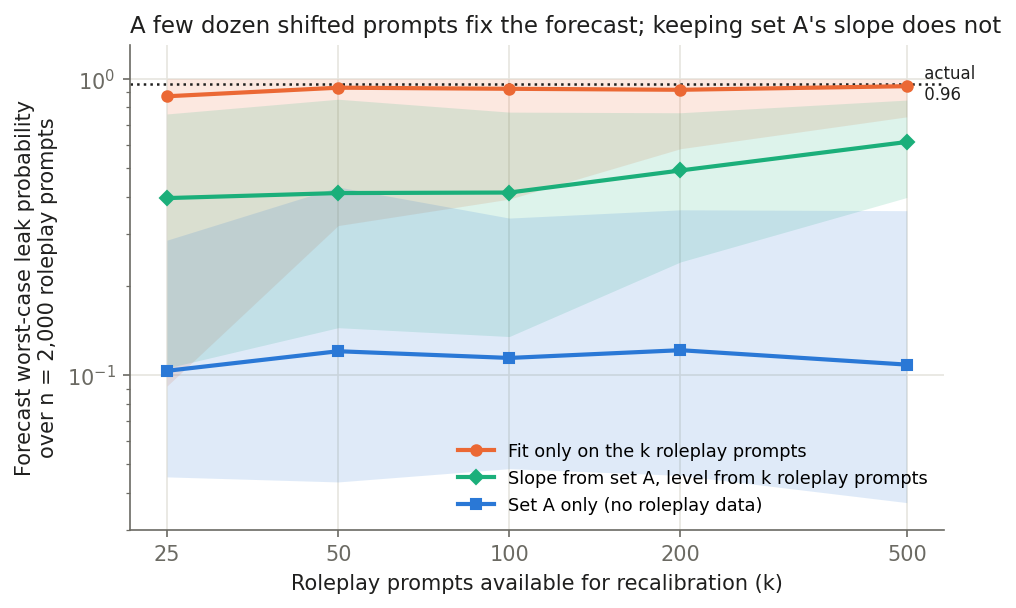

In [6]:
display(Image("results/fig3_recalibration.png"))